<a href="https://colab.research.google.com/github/jatinmulani/hotel_booking_dataset.ipynb/blob/main/Hotel_booking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Assignment: End-to-End Exploratory Data
Analysis (EDA), Data Cleaning, Outlier
Detection, Feature Engineering, and Machine
Learning Readiness

Dataset: Hotel Booking Demand Dataset

Business Scenario

You have been hired as a Data Analyst by a multinational hotel chain. The management wants to
understand booking behavior, cancellation patterns, customer preferences, seasonal trends, revenue
opportunities, and operational inefficiencies.
Your objective is to perform a complete End-to-End EDA, Data Cleaning, Data Quality Assessment,
Feature Engineering, and Machine Learning Readiness Analysis to support business decision-making.

Part 1: Dataset Understanding and Initial
Exploration

Task 1.1: Dataset Loading

Perform:
1. Load the dataset.
2. Display first 10 records.
3. Display last 10 records.
4. Check shape of dataset.
5. Display all columns.
6. Identify numerical and categorical columns.
7. Check memory usage.

In [ ]:
# <!-- 1 --> df=pd.read_csv('path')

# <!-- 2 -->df.head()

# <!-- 3 -->df.tail()

# <!-- 4 -->df.shape

# <!-- 5 -->df.columns

# <!-- 6 -->df.dtypes

# <!-- 7 --> df.memory_usage(deep=true)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessemostipak/hotel-booking-demand")

print("Path to dataset files:", path)

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_csv('/kaggle/input/hotel-booking-demand/hotel_bookings.csv')
df

In [ ]:
df.head(10)
df.tail(10)
df.shape
df.columns
df.dtypes
df.memory_usage(deep=True)

In [ ]:
df.columns.to_list()

In [ ]:
df[['hotel','is_canceled']]

Questions

1. How many bookings are present? [ROWS PRESENT IN THE DATASET]
2. How many features are available?
3. How many numerical features exist?
4. How many categorical features exist?
5. Which columns appear to be identifiers?
6. Which columns seem useful for predicting cancellations?

In [ ]:
# 1st => therre are 119390 rows are present in the dataset

In [ ]:
df.shape[0]

In [ ]:
# 2nd => there are 34 feature are present in the dataset

In [ ]:
df.shape[1]

In [ ]:
num_cols=df.select_dtypes(exclude='object')
num_cols.shape[1]

In [ ]:
cat_cols=df.select_dtypes(include='object')
cat_cols.shape[1]

Identifiers wo hote hain jo har row ko uniquely identify karte hain aur prediction me useful nahi hote.

In [ ]:
df.nunique().sort_values(ascending=False)

In [ ]:
#is_canceled ki madad se ham predict kr skte hai

Task 1.2: Dataset Overview

Generate:
info()
describe()
describe(include='object')
data type summary

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df.describe(include='object')

In [ ]:
df.dtypes  # DATA TYPE SUMMARY

Questions

1. Which feature has the highest average value?
2. Which feature has the largest variance?
3. Which feature has the smallest variance?
4. Which feature has the highest cardinality?
5. Which feature contains the most distinct categories?

 max() sirf value deta hai, column ka naam nahi
 isliye max ka use na krke sort_value use kiya

In [ ]:
num_df=df.select_dtypes(exclude='object')
print(type(num_df))
# high=num_df.mean().max()

num_df.mean().sort_values(ascending=False).head(1)

In [ ]:
num_df.var().sort_values(ascending=False).head(1)

In [ ]:
num_df.var().sort_values(ascending=True).head(1)

In [ ]:
df.nunique().sort_values(ascending=False).head(1)

In [ ]:
cat_df=df.select_dtypes(include='object')

In [ ]:
# df.select_dtypes(include='object').nunique().sort_values(ascending=False).head(1)
cat_df.nunique().sort_values(ascending=False).head(1)

Part 2: Data Quality Assessment

Calculate:
Total Missing Values


Missing Value Percentage

Create:
Missing Value Table


Missing Value Heatmap


Missing Value Bar Chart




In [ ]:
df.isnull().sum().sum()

In [ ]:
(df.isna().sum().sum()/df.size)*100 #whole dataset missing value percentage

In [ ]:
(df.isnull().sum() / len(df)) * 100  #columns wise missing value percentage

In [ ]:
missing_tablee=pd.DataFrame({
    'missing_value':df.isna().sum(),
    'missing_value_percentage':(df.isna().sum()/len(df))*100
})
missing_tablee=missing_tablee.sort_values(by='missing_value_percentage',ascending=False)
missing_tablee

In [ ]:
print(type(missing_tablee))

In [ ]:
sns.heatmap(df.isna())
plt.show()

In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0]
missing.sort_values(ascending=False).plot(
    kind='bar',
    figsize=(10,5)
)
plt.title('Missing Values by Column')
plt.ylabel('Count')
plt.show()

Business Insight Questions
1. Which columns have missing values?
2. Which column has the highest percentage of missing values?
3. Why might guests not provide this information?  -> btana hai ki missing values kyu aa ri
4. Would removing these records cause information loss?
5. Which columns should be imputed and which should be dropped?

In [ ]:
df.isna().sum().sort_values(ascending=False)
# 1st=> the columns which have null values are company ,agent,country,children

In [ ]:
missing_tablee['missing_value_percentage'].sort_values(ascending=False).head(1)
#2nd =>  compnay columns have highest missing value percentage => company

In [ ]:
# # 3rd => company most booking directly customer ne kiya hoga
# Company-sponsored booking nahi thi.
# agent
# Booking direct hotel website ya phone se hui hogi
# Koi travel agent involve nahi tha
# country
# Data entry miss ho sakti hai.
# Guest ne information provide nahi ki
# children
# Booking time par value fill nahi hui
# Data collection error

In [ ]:
# 4th
# company
# Column drop karne se information loss kam hoga kyunki 94% values missing hain

# agent
# Drop karna risky hai kyunki 86% data available hai
# Useful booking channel information lose ho sakti hai

# country
# Remove karna unnecessary hai
# Bahut kam missing values hain

# children
# Remove karna bilkul unnecessary hai
# Sirf kuch records missing hain

In [ ]:
# 5th
# company  -> drop
# agent -> impute
# country -> impute
# children -> impute

In [ ]:
# Drop company
# df.drop(columns=['company'], inplace=True)

# # Impute agent
df['agent'] = df['agent'].fillna(0)  #(0 logically indicate karta hai ki booking kisi agent ke through nahi aayi, jabki mode use karne se galat agent ID assign ho sakti hai.)

# # Impute country
df['country'] = df['country'].fillna(df['country'].mode()[0])

# # Impute children
df['children'] = df['children'].fillna(df['children'].median())

Task 2.2: Duplicate Analysis

Perform:
1. Detect duplicates.
2. Count duplicates.
3. Remove duplicates.

In [ ]:
df.duplicated().sum()

In [ ]:
df.duplicated().value_counts()

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

Questions

1. How many duplicate bookings exist?
2. Why can duplicate records distort hotel analytics?
3. How would duplicates impact revenue forecasting?

In [ ]:
# 1st => the total booking exist is something like 31994
# 2nd=> because its lead to miscalculation and miscaustion
# 3rd => becuse iit forcasting directly booking coun per depend karti hai
# agar duplicates present hai to expected  revencue acutal se jyada estimate hoga

Task 2.3: Unique Value Analysis

For every feature:
Calculate:

Number of unique values

Most frequent value

Frequency percentage

In [ ]:
df.nunique().sort_values(ascending=False)

In [ ]:
df.mode().iloc[0]

In [ ]:
result = pd.DataFrame({
    'Unique Values': df.nunique(),
    'Most Frequent Value': df.mode().iloc[0],
    'Frequency %': df.apply(
        lambda x: round(x.value_counts(normalize=True).iloc[0] * 100, 2)
    )
})

result

1. Which feature has the highest cardinality?
2. Which feature may act as a grouping variable?

3. Which feature would be difficult to encode directly?
 and =>Wo feature jisme bahut zyada unique values hon wo difficult hoega

Grouping variable wo hota hai jiske basis par data ko groups me divide karke analysis kar sakte ho

In [ ]:
# 1st adr column have the highest cardinality
# 2nd =>
df.groupby('hotel')['adr'].mean()
# grouping variable is hotel
# 3rd =>
df.nunique().sort_values(ascending=False).head()
# estimated_revenue is difficult in encodinf difficult hoega

Part 3: Data Cleaning

Task 3.1: Missing Value Treatment

For Numerical Columns:

Apply:

Mean Imputation

Median Imputation

For Categorical Columns:

Apply:

Mode Imputation

Unknown Category Imputation

In [ ]:
num_df=df.select_dtypes(exclude='object')
num_df


In [ ]:
num_df.fillna(num_df.mean(),inplace=True)

In [ ]:
num_df.fillna(num_df.median(),inplace=True)

In [ ]:
cat_df=df.select_dtypes(include='object')
cat_df

In [ ]:
cat_df.fillna(cat_df.mode().iloc[0], inplace=True)

In [ ]:
cat_df.fillna('unknown',inplace=True)

Questions

1. Which strategy worked best?
2. Why is median preferred for skewed data?
3. Which columns required special treatment?

In [ ]:
# 1st  if its normal numerical data go for mean if there is outliers present in dataset go for median if its categorical data go for mode
# 2nd because in skewed data there are outliers present in it
# 3rd => company and agent required special treatment because their missing values have
#  business meaning company had excessive missing values and was a candidate for dropping
#   while missing agent values may indicate direct bookings rather than missing information.

Task 3.2: Data Type Validation

Validate:
Numerical Columns
Categorical Columns
Date Columns

In [ ]:
len(num_df.columns)

In [ ]:
len(cat_df.columns)

In [ ]:
date_df=df.select_dtypes(include='datetime64')
len(date_df.columns)

Questions

1. Were any incorrect data types found?
2. How could incorrect data types affect business reports?
3. Which columns should be converted into categories?

Columns with a limited number of repeating values, such as hotel, meal, market_segment, distribution_channel, customer_type, and reservation_status, should be converted to category type to reduce memory usage and improve processing efficiency.

In [ ]:
df.shape[1]

In [ ]:
# 1st reservation_status_Date is stored in object type but it would have to stored in date_type format
#2nd  incorrect data lead to inaacurate aggregation , failed calculation
# 3rd
# Columns such as hotel, meal, market_segment, distribution_channel,
#  customer_type, reservation_status, is_canceled, and is_repeated_guest can be treated as categorical variables
#  because they represent discrete groups rather than continuous numerical measurements.

Part 4: Univariate Analysis

Task 4.1: Numerical Feature Analysis

For Every Numerical Feature

Calculate:

Mean    Median

Mode    variancce

Standard Deviation   min  max  range

Quartiles  Skewness

Create:

Histogram

KDE Plot

Boxplot

In [ ]:
num_df.describe().T

In [ ]:
summary=pd.DataFrame({
    'mean':num_df.mean(),
    'median':num_df.median(),
    'mode':num_df.mode().iloc[0],
    'variance':num_df.var(),
    'std':num_df.std(),
    'min':num_df.min(),
    'max':num_df.max(),
    'range':num_df.max()-num_df.min(),
    'skewness':num_df.skew(),
    'q1':num_df.quantile(0.25),
    'q2':num_df.quantile(0.50),
    'q3':num_df.quantile(0.75)
})
summary


In [ ]:
num_df.hist(figsize=(20,8))
plt.show()

In [ ]:
num_df.plot(kind='kde',figsize=(9,3))
plt.show()


In [ ]:
num_df.plot(kind='box',figsize=(5,6))
plt.show()

Business Insight Questions
1. What is the average lead time of bookings?
2. How far in advance do guests usually book?
3. Which feature has the highest variability?
4. Are there extreme booking behaviors?
5. Which variables are highly skewed?

In [ ]:
df['lead_time'].mean()
# 79.911 days is lead time of booking

In [ ]:
df['lead_time'].median()
# 69.0 is the advance time do guest really books

In [ ]:
df['lead_time'].std()
df['adr'].std()
df['days_in_waiting_list'].std()
# leadtime have the highest variability  => 106.8639

In [ ]:
# yes
# there are extreme booking behaviours

In [ ]:
# the highly skewed variable are leadtime,days in waiting list,prvioys cancelation ,adr

Task 4.2: Categorical Feature Analysis

For Every Categorical Feature

Calculate:

Frequency Count

Percentage Distribution

In [ ]:
cat_df

In [ ]:
cat_df.value_counts().T

In [ ]:
data=pd.DataFrame({
    'count':cat_df.value_counts(),
    'percentage':(cat_df.value_counts()/len(cat_df))*100
})
data

Create:

Countplots

Pie Charts

---





> value_counts() is necessary when creating a pie chart from a categorical column

A pie chart needs:
Categories (labels)
Their frequencies (sizes of slices)



because plot(kind='pie') expects numeric values, not raw category names.





In [ ]:
for col in cat_df:
  plt.figure(figsize=(8,8))
  df[col].value_counts().plot(kind='pie',autopct='%1.1f%%')
  plt.title(col)
  plt.show

In [ ]:
for col in cat_df:
  plt.figure(figsize=(8,8))
  sns.countplot(x=col,data=df)
  plt.title(col)
  plt.show()

Business Insight Questions
1. Which hotel receives more bookings?
2. Which market segment dominates bookings?
3. Which customer type is most common?
4. Which distribution channel generates most bookings?
5. Which country contributes most guests?
6. Which meal package is most popular?

In [ ]:
#1st city hotel recieves more booking
# 2nd online TA
# 3rd transient
# 4th TA/TO
# 5th PRT
# 6TH BB


Part 5: Hotel Business Analysis

Task 5.1: Cancellation Analysis

Analyze:
is_canceled

In [ ]:
is_canceled=df['is_canceled'].value_counts()
is_canceled
df['is_canceled']=df['is_canceled'].map({0:'not canceled',1:'canceled'})
df['is_canceled'].value_counts()

Create:
Countplot
Pie Chart

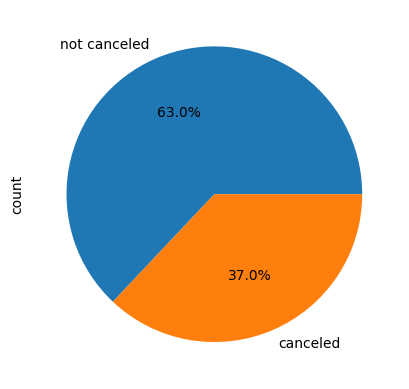

In [ ]:
df['is_canceled'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.show()

Important Business Questions
1. What is the cancellation rate?
2. What percentage of bookings are successfully completed?
3. How much potential revenue may be lost due to cancellations?
4. Which hotel experiences higher cancellations?

In [ ]:
df['total_nights'] = (
    df['stays_in_weekend_nights']
    + df['stays_in_week_nights']
)

df['revenue'] = df['adr'] * df['total_nights']

lost_revenue = df[df['is_canceled'] == 1]['revenue'].sum()

print(f"Potential Revenue Lost: ${lost_revenue:,.2f}")

In [ ]:
df['is_canceled_num'] = df['is_canceled'].map({
    'not canceled': 0,
    'canceled': 1
})

hotel_cancel_rate = (
    df.groupby('hotel')['is_canceled_num']
      .mean()
      * 100
).round(2)

print(hotel_cancel_rate)

In [ ]:
#1st the cancellation rates are 27.5%
#2nd 72.5% booking are successfully completed
#3rd there are 0 revenue lost
#4th city hotel have highest cancellation rate


Task 5.2: Seasonal Booking Analysis

Create:

Monthly booking trend

Year-wise booking trend

Month-Year heatmap

In [ ]:
month_order=['January','February','March','April','May','June','July','August','September','October','November','December']
df['arrival_date_month']=pd.Categorical(df['arrival_date_month'],categories=month_order,ordered=True)
df['arrival_date_month'].value_counts()

In [ ]:
sns.lineplot(x=df['arrival_date_month'],y=df['adr'])
plt.show()

In [ ]:
yearly=df['arrival_date_year'].value_counts().sort_index()
yearly

In [ ]:
sns.barplot(x=yearly.index,y=yearly.values)
plt.show()

In [ ]:
booking_pivot=pd.pivot_table(df,index='arrival_date_month',columns='arrival_date_year',values='is_canceled',aggfunc='sum')
booking_pivot

In [ ]:
booking_pivot = booking_pivot.reindex(month_order)

In [ ]:
heatmap_data = (
    df.groupby(['arrival_date_month','arrival_date_year'])
      .size()
      .unstack()
      .reindex(month_order))

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, annot=True, fmt='g', cmap='coolwarm')
plt.title('Monthly Bookings by Year')
plt.show()

Questions
1. Which month receives maximum bookings?
2. Which month receives minimum bookings?
3. Is there seasonality in hotel demand?
4. During which season should staffing be increased?

In [ ]:
# 1st
monthly_bookings = (
    df['arrival_date_month']
    .value_counts()
    .reindex(month_order)
)

print("Maximum Bookings Month:")
print(monthly_bookings.idxmax(), "-", monthly_bookings.max())
# 11257 is maximum bookings

In [ ]:
# 2nd
print("Minimum Bookings Month:")
print(monthly_bookings.idxmin(), "-", monthly_bookings.min())
# minimum 4691

In [ ]:
# 3rd
# Hotel demand shows clear seasonality,
# with booking volumes rising during holiday and
# vacation periods and falling during off-peak month

In [ ]:
# 4th
# Staffing should be increased during the summer season (June–August)
#  to handle higher guest volumes, check-ins, housekeeping requirements,
#  and customer service demand

Part 6: Outlier Detection

Task 6.1: IQR Method

For every numerical feature:

Calculate:

1. Q1
2. Q3
3. IQR
4. Lower Bound
5. Upper Bound

In [ ]:
num_cols=df.select_dtypes(exclude='object').columns
num_cols

In [ ]:
num_df = df.select_dtypes(include=['int64', 'float64'])

q1 = num_df.quantile(0.25)
q3 = num_df.quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr


Identify:
Number of Outliers

In [ ]:
for col in num_df:
  outliers=df[(df[col]<lower_bound[col]) | (df[col]>upper_bound[col])]
  print(f"{col} has {len(outliers)} outliers")
  # print(outliers)

lead_time has 3005 outliers
arrival_date_year has 0 outliers
arrival_date_week_number has 0 outliers
arrival_date_day_of_month has 0 outliers
stays_in_weekend_nights has 265 outliers
stays_in_week_nights has 3354 outliers
adults has 29710 outliers
children has 8590 outliers
babies has 917 outliers
is_repeated_guest has 3810 outliers
previous_cancellations has 6484 outliers
previous_bookings_not_canceled has 3620 outliers
booking_changes has 18076 outliers
agent has 0 outliers
company has 0 outliers
days_in_waiting_list has 3698 outliers
adr has 3793 outliers
required_car_parking_spaces has 7416 outliers
total_of_special_requests has 2877 outliers
stay_duration has 5257 outliers
estimated_revenue has 7692 outliers


Create:
Boxplots

In [ ]:
# df.plot(kind='box')
# sns.boxplot(x=df['lead_time'])
for col in num_df.columns:
  sns.boxplot(x=df[col])
plt.xticks(rotation=90)
plt.show()

Questions

1. Which feature contains most outliers?
2. Are outliers genuine customer behavior or data errors?
3. Which outliers represent high-value bookings?

In [ ]:
outlier_count = {}

for col in num_df.columns:
    outliers = df[(df[col] < lower_bound[col]) |
                  (df[col] > upper_bound[col])]

    outlier_count[col] = len(outliers)

outlier_count = pd.Series(outlier_count).sort_values(ascending=False)

print(outlier_count)
# Adults contains the highest number of outliers (22,882)

adults                            29710
booking_changes                   18076
children                           8590
estimated_revenue                  7692
required_car_parking_spaces        7416
previous_cancellations             6484
stay_duration                      5257
is_repeated_guest                  3810
adr                                3793
days_in_waiting_list               3698
previous_bookings_not_canceled     3620
stays_in_week_nights               3354
lead_time                          3005
total_of_special_requests          2877
babies                              917
stays_in_weekend_nights             265
arrival_date_year                     0
arrival_date_day_of_month             0
arrival_date_week_number              0
agent                                 0
company                               0
dtype: int64


In [ ]:
# 2nd
# from the hotel booking dataset
# High lead_time → guests booking far in advance → genuine
# High adr → luxury rooms, peak season → genuine
# High revenue → long stays or expensive rooms → genuine
# Very high adults values (e.g., 20+ or 50+) → possible data issues

In [ ]:
# 3rd
high_value = df.sort_values('revenue', ascending=False)

high_value[['hotel','adr','total_nights','revenue']].head(10)
# df[df['adr'] > upper_bound['adr']]

Task 6.2: Z-Score Method

Calculate:
Z-score
Identify:
|Z| > 3

In [ ]:
z_scores = pd.DataFrame()

for col in num_df.columns:
    z_scores[col] = (num_df[col] - num_df[col].mean()) / num_df[col].std()

In [ ]:
z_outlier_count = {}

for col in num_df.columns:
    outliers = z_scores[abs(z_scores[col]) > 3]

    z_outlier_count[col] = len(outliers)

z_outlier_count = pd.Series(z_outlier_count).sort_values(ascending=False)

print(z_outlier_count)

required_car_parking_spaces       7416
is_repeated_guest                 3810
children                          3729
total_of_special_requests         2877
estimated_revenue                 2541
stays_in_weekend_nights           2199
days_in_waiting_list              1871
stay_duration                     1720
stays_in_week_nights              1669
booking_changes                   1570
lead_time                         1454
adr                               1138
previous_bookings_not_canceled     936
babies                             917
agent                              797
adults                             481
previous_cancellations             317
arrival_date_day_of_month            0
arrival_date_week_number             0
arrival_date_year                    0
company                              0
dtype: int64


In [ ]:
adr_outliers = df[abs(z_scores['adr']) > 3]

print(adr_outliers.shape)
adr_outliers.head()

In [ ]:
print("Feature with most Z-score outliers:")
print(z_outlier_count.idxmax())

Questions

1. Compare IQR and Z-score methods.
2. Which method works better on skewed hotel data?

1. | Aspect                       | IQR Method                                  | Z-Score Method              |   |      |
| ---------------------------- | ------------------------------------------- | --------------------------- | - | ---- |
| Based on                     | Quartiles (Q1, Q3)                          | Mean and Standard Deviation |   |      |
| Formula                      | Outlier if outside Q1−1.5×IQR or Q3+1.5×IQR | Outlier if (                | Z | > 3) |
| Sensitive to Outliers?       | No                                          | Yes                         |   |      |
| Assumes Normal Distribution? | No                                          | Yes                         |   |      |
| Works with Skewed Data?      | Yes                                         | Not very well               |   |      |
| Robustness                   | High                                        | Lower                       |   |      |


In [ ]:
# 2nd => For the Hotel Booking dataset, many variables are highly skewed:
# lead_time
# adr
# revenue
# days_in_waiting_list
# previous_cancellations

# Because these variables are not normally distributed, IQR performs better.

Part 7: Outlier Treatment

Apply:
Method 1

Remove Outliers

Method 2

Capping
Method 3

Winsorization

remove outliers by iqr

In [ ]:
df_removed = df.copy()

for col in num_df.columns:
    df_removed = df_removed[
        (df_removed[col] >= lower_bound[col]) &
        (df_removed[col] <= upper_bound[col])
    ]

print("Original Shape:", df.shape)
print("After Removing Outliers:", df_removed.shape)

Original Shape: (119390, 35)
After Removing Outliers: (25, 35)


All observations outside the acceptable IQR range are removed.

Method 2: Capping (Clipping)

In [ ]:
df_capped = df.copy()

for col in num_df.columns:
    df_capped[col] = df_capped[col].clip(
        lower=lower_bound[col],
        upper=upper_bound[col]
    )

In [ ]:
df_capped[num_df.columns].describe()

 In capping metthod => Extreme values are replaced by boundary values while retaining all record

Method 3: Winsorization

Winsorization replaces extreme values using percentile thresholds.

In [ ]:
df_winsor = df.copy()
for col in num_df.columns:
    lower = df_winsor[col].quantile(0.05)
    upper = df_winsor[col].quantile(0.95)
    df_winsor[col] = df_winsor[col].clip(lower, upper)

In [ ]:
df_winsor[num_df.columns].describe()

Values below the 5th percentile are replaced by the 5th percentile, and values above the 95th percentile are replaced by the 95th percentile.

Questions

1. Which method preserves maximum data?
2. Which method changes distribution significantly?
3. Which method would be recommended for business analytics?

In [ ]:
# 1st =>Capping and Winsorization
# 2nd =>Outlier Removal
# 3rd=>Winsorization

Part 8: Feature Engineering=>
Create At Least 10 New Features

Feature 1

Total Guests
Adults + Children + Babies

Feature 2

Stay Duration
Weekend Nights + Week Nights

Feature 3

Booking Season
Winter / Summer / Monsoon

Feature 4

Lead Time Category
Short / Medium / Long

Feature 5

Guest Type
Solo / Couple / Family

Feature 6

Booking Risk Score
Based on:
Lead Time
Previous Cancellations

Deposit Type

Feature 7

Revenue Opportunity Score
Based on:
Stay Duration
ADR

Feature 8

High Value Customer
Based on ADR percentile

Feature 9

Advance Booking Group

Feature 10

Special Request Category
Low / Medium / High

In [ ]:
# 1st
df['total_guests'] = df['adults'] + df['children'] + df['babies']

In [ ]:
# 2nd
df['stay_duration'] = (df['stays_in_weekend_nights']+df['stays_in_week_nights'])

In [ ]:
# 3rd
season_map = {'December':'Winter','January':'Winter','February':'Winter','March':'Summer','April':'Summer','May':'Summer',
              'June':'Monsoon','July':'Monsoon','August':'Monsoon','September':'Monsoon','October':'Monsoon','November':'Winter'}
df['booking_season'] = df['arrival_date_month'].map(season_map)

In [ ]:
# 4th
df['lead_time_category'] = pd.cut(df['lead_time'],bins=[-1,30,90,1000],
                                  labels=['Short','Medium','Long']
)

In [ ]:
# 5th
def guest_type(row):
    if row['total_guests'] == 1:
        return 'Solo'
    elif row['total_guests'] == 2:
        return 'Couple'
    else:
        return 'Family'

df['guest_type'] = df.apply(guest_type, axis=1)

In [ ]:
risk_score = (
    (df['lead_time']/df['lead_time'].max())*40 +
    (df['previous_cancellations']/
     max(df['previous_cancellations'].max(),1))*40
)

deposit_score = {
    'No Deposit':20,
    'Refundable':10,
    'Non Refund':0
}

df['booking_risk_score'] = (
    risk_score +
    df['deposit_type'].map(deposit_score)
).round(0)

In [ ]:
df['revenue_opportunity_score'] = (
    df['stay_duration'] * df['adr']
)

In [ ]:
adr_threshold = df['adr'].quantile(0.75)

df['high_value_customer'] = (
    df['adr'] >= adr_threshold
).astype(int)

In [ ]:
df['advance_booking_group'] = pd.cut(
    df['lead_time'],
    bins=[-1,7,30,90,1000],
    labels=[
        'Last Minute',
        'Short Advance',
        'Medium Advance',
        'Long Advance'
    ]
)

In [ ]:
df['special_request_category'] = pd.cut(
    df['total_of_special_requests'],
    bins=[-1,1,3,10],
    labels=['Low','Medium','High']
)

Questions

1. Which engineered feature is most useful?
2. Which feature can help predict cancellations?
3. Which feature helps revenue analysis most?

In [ ]:
# 1st => booking risk score is mode useful
# 2nd => booking_risk_score help predicts cancellation
# 3rd => Revenue Opportunity Score

Part 9: Bivariate Analysis

Numerical vs Numerical

Create:

Correlation Matrix

Heatmap

Scatterplots

In [ ]:
corr_matrix = num_df.corr()

corr_matrix

In [ ]:
plt.figure(figsize=(14,10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

In [ ]:
sns.scatterplot(x='lead_time', y='adr', data=df)
plt.show()

In [ ]:
sns.scatterplot(x='stay_duration', y='revenue', data=df)
plt.show()

In [ ]:
sns.scatterplot(x='total_guests', y='revenue', data=df)
plt.show()

Questions

1. Which variables are highly correlated?
2. Does lead time affect ADR?
3. Does stay duration affect revenue?

In [ ]:
# 1st =>
corr_matrix['revenue'].sort_values(ascending=False)


In [ ]:
# 2nd
sns.scatterplot(x='stay_duration', y='revenue', data=df)

In [ ]:
# 3rd
sns.scatterplot(x='lead_time', y='adr', data=df)

In [ ]:
# 4th
sns.scatterplot(x='total_guests', y='revenue', data=df)

Numerical vs Categorical

Create:
Boxplots
Violinplots
Grouped Statistics

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='hotel', y='adr', data=df)
plt.title('ADR by Hotel')
plt.show()

In [ ]:
plt.figure(figsize=(12,5))
sns.boxplot(x='market_segment', y='adr', data=df)
plt.xticks(rotation=45)
plt.title('ADR by Market Segment')
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='customer_type', y='stay_duration', data=df)
plt.title('Stay Duration by Customer Type')
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
sns.violinplot(x='hotel', y='adr', data=df)
plt.title('ADR Distribution by Hotel')
plt.show()

In [ ]:
df.groupby('hotel')['adr'].agg(['mean','median','max'])

Questions
1. Which hotel has the highest ADR?
2. Which market segment spends most?
3. Which customer type stays longest?

In [ ]:
# 1st
df.groupby('hotel')['adr'].mean().sort_values(ascending=False)
# The hotel with the highest average ADR charges premium room rates
# and contributes more revenue per booking

In [ ]:
# 2nd
df.groupby('market_segment')['revenue'].mean().sort_values(ascending=False)
# This segment generates the highest revenue and should be targeted
#  through marketing and loyalty programs

In [ ]:
# 3rd
df.groupby('customer_type')['stay_duration'].mean().sort_values(ascending=False)
# Customers with the longest average stay contribute more room nights and potentially higher revenue

Categorical vs Categorical

Create:
Crosstabs
Heatmaps

In [ ]:
pd.crosstab(
    df['deposit_type'],
    df['is_canceled']
)

In [ ]:
pd.crosstab(
    df['deposit_type'],
    df['is_canceled'],
    normalize='index'
)*100

In [ ]:
ct = pd.crosstab(
    df['deposit_type'],
    df['is_canceled'],
    normalize='index'
)*100

plt.figure(figsize=(8,5))
sns.heatmap(ct, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Cancellation vs Deposit Type')
plt.show()

Questions

1. Is cancellation associated with deposit type?
2. Is cancellation associated with market segment?
3. Is cancellation associated with customer type?

In [ ]:
# 1st =>Yes. Cancellation rates vary significantly across deposit types. Non-refundable deposits generally reduce cancellations

In [ ]:
# 2. Is cancellation associated with market segment?
# Yes. Certain market segments, especially online travel agencies and group bookings, tend to experience higher cancellation rates.

In [ ]:
# 3. Is cancellation associated with customer type?
# Yes. Customer type influences cancellation behavior,
#  with some customer groups showing greater booking commitment than others.

In [ ]:
# 2nd
market_cancel=pd.crosstab(
    df['market_segment'],
    df['is_canceled']
)
plt.figure(figsize=(10,6))
sns.heatmap(
    market_cancel,
    annot=True,
    fmt='.1f',
    cmap='coolwarm'
)
plt.title('Cancellation vs Market Segment')
plt.show()

Some market segments (often Online TA or Groups) tend to exhibit higher cancellation rates than others

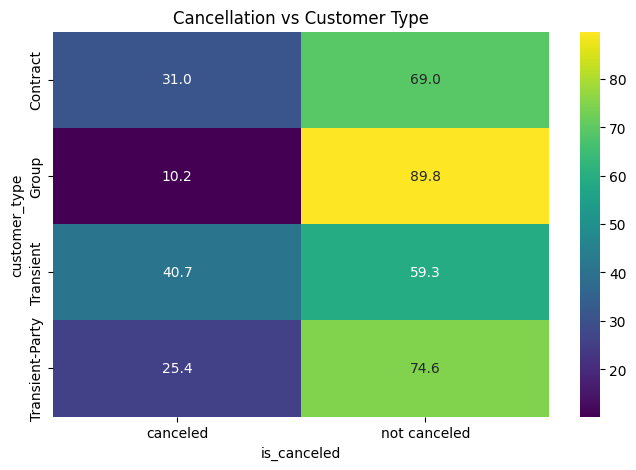

In [ ]:
customer_cancel = pd.crosstab(
    df['customer_type'],
    df['is_canceled'],
    normalize='index'
)*100

plt.figure(figsize=(8,5))
sns.heatmap(
    customer_cancel,
    annot=True,
    fmt='.1f',
    cmap='viridis'
)
plt.title('Cancellation vs Customer Type')
plt.show()

Certain customer types may cancel more frequently. For example, transient customers often have higher cancellation rates than contract customers.

Part 10: Deep Business Insight Analysis

Revenue Analysis

Create:
Estimated Revenue
ADR × Stay Duration

In [ ]:
df['estimated_revenue'] = df['adr'] * df['stay_duration']


Questions

1. Which hotel generates highest revenue?
2. Which month generates highest revenue?
3. Which customer segment generates most revenue?
4. Which country contributes most revenue?

In [ ]:
hotel_revenue = df.groupby('hotel')['estimated_revenue'].sum()
hotel_revenue.sort_values(ascending=False)

In [ ]:
hotel_revenue.sort_values().plot(kind='barh')
plt.title('Revenue by Hotel')
plt.xlabel('Revenue')
plt.show()

The hotel with the highest total revenue contributes the largest share of overall business and should be prioritized for revenue management strategies.

In [ ]:
# 2nd
month_revenue = df.groupby('arrival_date_month')['estimated_revenue'].sum()
month_revenue = month_revenue.reindex([
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
])
month_revenue.plot(kind='bar')
plt.title('Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()
print(month_revenue.sort_values(ascending=False))

The highest-revenue month corresponds to peak travel demand and should receive increased staffing and promotional focus.

In [ ]:
segment_revenue = df.groupby(
    'market_segment'
)['estimated_revenue'].sum()

print(segment_revenue.sort_values(ascending=False))
plt.figure(figsize=(10,5))

segment_revenue.sort_values().plot(kind='barh')

plt.title('Revenue by Market Segment')
plt.show()

The top revenue-generating segment represents the most valuable source of customers and should be targeted through marketing campaigns.

In [ ]:
# 4th
country_revenue = df.groupby(
    'country'
)['estimated_revenue'].sum()

country_revenue.sort_values(ascending=False)
plt.figure(figsize=(10,5))

country_revenue.sort_values(
    ascending=False
).head(10).plot(kind='bar')

plt.title('Top 10 Revenue-Contributing Countries')
plt.ylabel('Revenue')
plt.show()

The country contributing the most revenue represents the hotel's most valuable geographic market and can be prioritized for international marketing efforts.

Cancellation Risk Analysis

Questions

1. Which customer type cancels most?
2. Which market segment cancels most?
3. Which booking channel has highest cancellation?
4. Which deposit type has highest cancellation?

In [ ]:
# 1st
df = pd.read_csv('/kaggle/input/hotel-booking-demand/hotel_bookings.csv')

print(df.head())
print(df['is_canceled'].unique())

In [ ]:
# 2nd
market_cancel = (
    df.groupby('market_segment')['is_canceled']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

market_cancel

In [ ]:
# 3rd
customer_cancel = (
    df.groupby('customer_type')['is_canceled']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

customer_cancel

In [ ]:
channel_cancel = (
    df.groupby('distribution_channel')['is_canceled']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

channel_cancel

In [ ]:
deposit_cancel = (
    df.groupby('deposit_type')['is_canceled']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

deposit_cancel

Customer Behavior Analysis

Questions

1. Who books furthest in advance?
2. Who stays longest?
3. Which guests make special requests most often?
4. Which guest group is most profitable?

In [ ]:
advance_booking = (
    df.groupby('customer_type')['lead_time']
      .mean()
      .sort_values(ascending=False)
)

print(advance_booking)

In [ ]:
advance_booking.plot(kind='bar')
plt.title('Average Lead Time by Customer Type')
plt.ylabel('Average Days Before Arrival')
plt.show()

In [ ]:
# 2nd
df['stay_duration'] = (
    df['stays_in_weekend_nights'] +
    df['stays_in_week_nights']
)
longest_stay = (
    df.groupby('customer_type')['stay_duration']
      .mean()
      .sort_values(ascending=False)
)

longest_stay

In [ ]:
# 3rd
special_requests = (
    df.groupby('customer_type')['total_of_special_requests']
      .mean()
      .sort_values(ascending=False)
)

special_requests

In [ ]:
# 4th
df['estimated_revenue'] = (
    df['adr'] * df['stay_duration']
)
profitability = (
    df.groupby('customer_type')['estimated_revenue']
      .mean()
      .sort_values(ascending=False)
)

profitability

Part 11: Data Transformation

Apply:

StandardScaler

MinMaxScaler

RobustScaler

Compare:

Mean

Standard Deviation

Distribution

In [ ]:
num_df

num_df khud ek dataset hai columns ka name nhi isliye iske sath hamne df[num_df] use ni kra

In [ ]:
stndard_Scaler=(num_df-num_df.mean())/num_df.std()
stndard_Scaler.head()

In [ ]:
minmaxscaler=(num_df-num_df.min())/(num_df.max()-num_df.min())
minmaxscaler.head()

In [ ]:
robust_scaler=(num_df-num_df.median())/iqr
robust_scaler

In [ ]:
comparison = pd.DataFrame({
    'Original Mean': num_df.mean(),
    'StandardScaler Mean': stndard_Scaler.mean(),
    'MinMaxScaler Mean': minmaxscaler.mean(),
    'RobustScaler Mean': robust_scaler.mean(),

    'Original Std': num_df.std(),
    'StandardScaler Std': stndard_Scaler.std(),
    'MinMaxScaler Std': minmaxscaler.std(),
    'RobustScaler Std': robust_scaler.std()
})

comparison.head()

Questions

1. Which scaler handled outliers best?
2. Which scaler would you use before KNN?
3. Which scaler would you use before Neural Networks?

In [ ]:
# 1st => RobustScaler handled outliers best
# Reason:
# 1. Uses Median and IQR (Interquartile Range) instead of Mean and Standard Deviation.
# 2. Extreme values have much less impact.

In [ ]:
# 2nd => StandardScaler
# StandardScaler is preferred before KNN because KNN relies on distance calculations and performs
# best when features are standardized.

In [ ]:
# 3rd =>MinMaxScaler
# MinMaxScaler is commonly used before Neural Networks because it scales features to a fixed range (0–1),
#  improving training stability and convergence.

Part 12: Skewness Analysis

Calculate skewness for all numerical features

Apply:

Log Transformation

Square Root Transformation

In [ ]:
skewness=num_df.skew().sort_values(ascending=False)
skewness

In [ ]:
log_transformation = num_df.copy()
for col in log_transformation.columns:
    if (log_transformation[col] >= 0).all():
        log_transformation[col] = np.log1p(log_transformation[col])
log_skew=log_transformation.skew()

In [ ]:
sqr=num_df.copy()
for col in sqr:
  if(sqr[col]>=0).all():
    sqr[col]=np.sqrt(sqr[col])
sqr_skew=sqr.skew()

Compare:

Before
 and After

In [ ]:
comparison = pd.DataFrame({
    'Original Skewness': skewness,
    'Log Transform': log_skew,
    'Sqrt Transform': sqr_skew
})

comparison.sort_values(ascending=False,by='Original Skewness')

Questions

1. Which feature was most skewed?
2. Which transformation improved normality most?
3. Why is skewness harmful for certain ML algorithms?

In [ ]:
# 1st => previous cancellation feature have the most skewed

In [ ]:
# 2nd
log_improvement = (
    abs(comparison['Original Skewness']) -
    abs(comparison['Log Transform'])
).mean()

sqrt_improvement = (
    abs(comparison['Original Skewness']) -
    abs(comparison['Sqrt Transform'])
).mean()

print("Log Improvement:", log_improvement)
print("Sqrt Improvement:", sqrt_improvement)
# log transformation improved most

In [ ]:
# 3rd
# It increases the impact of outliers, distorts distances, violates model assumptions, and can reduce ML model performance.


Part 13: Data Engineering Quality Checks

Create rules for:

Null Validation

Examples:

ADR should not be null.

Hotel should not be null.

In [ ]:
critical_cols = [
    'hotel',
    'is_canceled',
    'lead_time',
    'arrival_date_year',
    'arrival_date_month',
    'adults',
    'adr',
    'customer_type',
    'market_segment',
    'distribution_channel',
    'deposit_type'
]
for col in critical_cols:
    null_count = df[col].isnull().sum()
    print(f"{col}: {null_count} null values")

Negative Values
Examples:
Lead Time < 0
ADR < 0
Adults < 0

In [ ]:
negative_rules = [
    'lead_time',
    'adr',
    'adults',
    'children',
    'babies',
    'booking_changes',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'days_in_waiting_list',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

for col in negative_rules:
    count = (df[col] < 0).sum()
    print(f"{col}: {count} negative values")

Business Rules

Examples:
Adults + Children + Babies > 0
ADR > 0
Stay Duration > 0

In [ ]:
invalid_guests = df[
    (df['adults'] + df['children'] + df['babies']) <= 0
]

print("Invalid Guest Records:", len(invalid_guests))

In [ ]:
invalid_adr = df[df['adr'] <= 0]

print("Invalid ADR Records:", len(invalid_adr))

In [ ]:
invalid_stay = df[df['stay_duration'] <= 0]

print("Invalid Stay Records:", len(invalid_stay))

In [ ]:
invalid_revenue = df[df['estimated_revenue'] < 0]

print("Invalid Revenue Records:", len(invalid_revenue))

In [ ]:
# Validation Summary Report
business_rules = pd.DataFrame({
    'Rule': [
        'Adults + Children + Babies > 0',
        'ADR > 0',
        'Stay Duration > 0',
        'Estimated Revenue >= 0'
    ],
    'Invalid Records': [
        ((df['adults'] + df['children'] + df['babies']) <= 0).sum(),
        (df['adr'] <= 0).sum(),
        (df['stay_duration'] <= 0).sum(),
        (df['estimated_revenue'] < 0).sum()
    ]
})

business_rules

Data Type Rules
Examples:
Hotel → String
ADR → Numeric
Arrival Date → Datetime

In [ ]:
df.dtypes

In [ ]:
# Create Data Type Report
dtype_report = pd.DataFrame({
    'Column': df.columns,
    'Actual_Type': df.dtypes.values
})

dtype_report

Questions

1. Which rules failed?
2. Which records violate business constraints?
3. How would you automate these checks?

In [ ]:
# 1st
validation_summary = pd.DataFrame({
    'Rule': [
        'Adults + Children + Babies > 0',
        'ADR > 0',
        'Stay Duration > 0',
        'Lead Time >= 0'
    ],
    'Failed_Records': [
        ((df['adults'] + df['children'] + df['babies']) <= 0).sum(),
        (df['adr'] <= 0).sum(),
        (df['stay_duration'] <= 0).sum(),
        (df['lead_time'] < 0).sum()
    ]
})


validation_summary
failed_rules = validation_summary[
    validation_summary['Failed_Records'] > 0
]

failed_rules

In [ ]:
# 2nd
print("Invalid Guest Records:", len(invalid_guests))
print("Invalid ADR Records:", len(invalid_adr))
print("Invalid Stay Records:", len(invalid_stay))
# Records with zero guests, non-positive ADR, or non-positive stay duration violated the defined business constraints and should be reviewed or removed.

In [ ]:
# 3rd
# Build reusable validation functions and execute them automatically during data ingestion and preprocessing
def validate_hotel_data(df):

    errors = {}

    errors['Invalid Guests'] = (
        (df['adults'] + df['children'] + df['babies']) <= 0
    ).sum()

    errors['Invalid ADR'] = (
        df['adr'] <= 0
    ).sum()

    errors['Invalid Stay Duration'] = (
        df['stay_duration'] <= 0
    ).sum()

    errors['Negative Lead Time'] = (
        df['lead_time'] < 0
    ).sum()

    return pd.DataFrame(
        errors.items(),
        columns=['Rule','Failed Records']
    )

validate_hotel_data(df)

Part 14: Machine Learning Readiness
Assessment

Prepare a complete ML Readiness Report.
Include:

Columns to Drop
Explain why.

Columns to Encode

Choose:

Label Encoding

One Hot Encoding

Columns to Scale


Explain why.

Highly Correlated Features

Recommend whether to keep or remove.

Feature Selection

Select top features for cancellation prediction.

In [ ]:
drop_cols = [
    'reservation_status',
    'reservation_status_date',
    'company',
    'agent'
]

df.columns
df_ml=df.drop(columns=drop_cols)
df_ml.columns
# if we want to delete in origanl df we use inplacce=true so it will delete permanenetley

In [ ]:
# label encoding => Use when categories have few unique values.
label_cols = [
    'deposit_type',
    'customer_type'
]

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in label_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

Reason:

Small number of categories

Easy transformation

In [ ]:
# one hot encoding =>Use when categories are nominal (no order).
onehot_cols = [
    'hotel',
    'meal',
    'market_segment',
    'distribution_channel',
    'reserved_room_type',
    'assigned_room_type'
]

In [ ]:
df_ml.info()

In [ ]:
df_ml = pd.get_dummies(
    df_ml,
    columns=onehot_cols,
    drop_first=True
)
df_ml.columns

Index(['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'country', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'deposit_type',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'hotel_Resort Hotel', 'meal_FB', 'meal_HB', 'meal_SC', 'meal_Undefined',
       'market_segment_Complementary', 'market_segment_Corporate',
       'market_segment_Direct', 'market_segment_Groups',
       'market_segment_Offline TA/TO', 'market_segment_Online TA',
       'market_segment_Undefined', 'distribution_channel_Direct',
       'distribution_channel_GDS', 'distribution_channel_TA/TO',
       'distribution_channel_Undefined', 'reserved_room_type_B',
       'reserved_room_type_C', 'reserv

Reason:

No natural order exists

Prevents introducing false relationships

In [ ]:
# 3. Columns to Scale
scale_cols = [
    'lead_time',
    'adr',
    'adults',
    'children',
    'babies',
    'booking_changes',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'days_in_waiting_list',
    'total_of_special_requests'
]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_ml[scale_cols] = scaler.fit_transform(
    df_ml[scale_cols]
)

Reason:

Features have very different ranges

Scaling prevents large-valued features from dominating

In [ ]:
# highly  correalted
corr = num_df.corr()

corr[abs(corr) > 0.8]

Remove one of the pair to reduce multicollinearity.

In [ ]:
# feature selection for cancellation predection
selected_features = [
    'lead_time',
    'deposit_type',
    'previous_cancellations',
    'market_segment',
    'customer_type',
    'adr',
    'booking_changes',
    'total_of_special_requests',
    'days_in_waiting_list',
    'distribution_channel',
    'stay_duration'
]
from sklearn.ensemble import RandomForestClassifier

X = df[selected_features]
y = df['is_canceled']

Questions

1. Which features are most important for predicting cancellations?
2. Which features may cause data leakage?
3. Which features should be excluded?

In [ ]:
# 1st =>Lead Time, Deposit Type, Previous Cancellations, Market Segment, and ADR are typically the strongest predictors
# of hotel booking cancellations.

In [ ]:
# # 2nd
# A feature causes leakage when it contains information that would not be available at the time you're trying to predict cancellation.
# For hotel booking datasets, the biggest leakage risks are:
#  Feature                    Reason

# reservation_status          Directly reveals final booking outcome
# reservation_status_date     Recorded after cancellation or check-in occurs


In [ ]:
# # 3rd
# reservation_status
# reservation_status_date

Part 15: Executive Business Insights Report

Generate at least 15 business insights supported by visualizations.
Important Insight Questions

1. Why are customers cancelling bookings?
2. Which hotel performs better?
3. Which market segment generates maximum revenue?
4. Which countries generate most bookings?
5. Which booking channel performs best?
6. What is the peak booking season?
7. Which customer type is most valuable?
8. Which deposit type reduces cancellations?
9. Does booking early increase cancellation probability?
10. Which guest type stays longest?
11. Which guests make most special requests?
12. Which months require maximum staffing?
13. Which segment should receive marketing focus?
14. Which factors most influence cancellations?
15. How can the hotel increase occupancy and revenue?

In [ ]:
sns.barplot(
    x='deposit_type',
    y='is_canceled',
    data=df
)
plt.title('Cancellation Rate by Deposit Type')

In [ ]:
df.to_csv('hotel_bookings_clean.csv', index=False)

Bonus Challenge (30 Marks)

Create a reusable OOP project:

class HotelBookingAnalyzer:
pass

The class should automatically:
Generate Dataset Summary
Detect Missing Values
Detect Duplicates
Detect Outliers
Generate EDA Report
Generate Business Insights
Generate Revenue Analysis
Generate Cancellation Analysis
Generate Data Quality Report
Generate ML Readiness Report
Export Reports as PDF
Submission Requirements

1. Jupyter Notebook (.ipynb)
2. Cleaned Dataset (.csv)
3. Data Quality Report (.pdf)
4. Business Insights Report (.pdf)
5. Machine Learning Readiness Report (.pdf)

In [ ]:
import pandas as pd
import numpy as np

class HotelBookingAnalyzer:

    def __init__(self, df):
        self.df = df

    def dataset_summary(self):
        print("===== DATASET SUMMARY =====")
        print("Shape:", self.df.shape)
        print("\nColumns:")
        print(self.df.columns.tolist())

    def missing_values(self):
        print("\n===== MISSING VALUES =====")
        print(self.df.isnull().sum())

    def duplicate_analysis(self):
        print("\n===== DUPLICATES =====")
        print("Duplicate Rows:", self.df.duplicated().sum())

    def outlier_detection(self):

        print("\n===== OUTLIERS =====")

        num_cols = self.df.select_dtypes(include=np.number).columns

        for col in num_cols:

            q1 = self.df[col].quantile(0.25)
            q3 = self.df[col].quantile(0.75)

            iqr = q3 - q1

            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr

            outliers = self.df[
                (self.df[col] < lower) |
                (self.df[col] > upper)
            ].shape[0]

            print(col, ":", outliers)

    def revenue_analysis(self):

        print("\n===== REVENUE ANALYSIS =====")

        self.df['total_stay'] = (
            self.df['stays_in_week_nights']
            + self.df['stays_in_weekend_nights']
        )

        self.df['revenue'] = (
            self.df['adr']
            * self.df['total_stay']
        )

        print(
            self.df.groupby('hotel')['revenue']
            .sum()
            .sort_values(ascending=False)
        )

    def cancellation_analysis(self):

        print("\n===== CANCELLATION ANALYSIS =====")

        print(
            self.df.groupby('customer_type')['is_canceled']
            .mean()
            .sort_values(ascending=False)
        )

    def ml_readiness_report(self):

        print("\n===== ML READINESS REPORT =====")

        print("\nColumns To Drop:")
        print([
            'reservation_status',
            'reservation_status_date',
            'company',
            'agent'
        ])

        print("\nTarget Variable:")
        print("is_canceled")

    def run_complete_analysis(self):

        self.dataset_summary()
        self.missing_values()
        self.duplicate_analysis()
        self.outlier_detection()
        self.revenue_analysis()
        self.cancellation_analysis()
        self.ml_readiness_report()

In [ ]:
df = pd.read_csv('/content/hotel_bookings_clean.csv')

analyzer = HotelBookingAnalyzer(df)

analyzer.run_complete_analysis()